# 🦋 Thyroid Cancer Recurrence Prediction
## Comprehensive EDA + Model Building

**Dataset:** Thyroid Differentiated Cancer Recurrence (383 patients, 17 features)  
**Target:** `Recurred` — whether thyroid cancer recurred (Yes/No)  

---
### Pipeline Overview
1. Data Loading & Inspection
2. Exploratory Data Analysis (EDA)
   - Numerical feature analysis
   - Categorical feature analysis
   - Correlation heatmap
   - Statistical significance tests
3. Feature Engineering & Encoding
4. Model Building & Evaluation
   - Logistic Regression
   - Decision Tree
   - Random Forest
5. Model Comparison & Feature Importance

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import chi2_contingency

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, ConfusionMatrixDisplay
)

# Plot style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='Set2')

print('All libraries loaded successfully ✅')

All libraries loaded successfully ✅


## 2. Data Loading & Basic Inspection

In [2]:
df = pd.read_csv('Thyroid_Diff.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (383, 17)


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [3]:
# Dtypes and null check
print('='*60)
print('DATASET INFO')
print('='*60)
df.info()
print('\n')
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 n

In [4]:
# Descriptive statistics for numerical feature
print('Descriptive Statistics (Numerical):')
df.describe()

Descriptive Statistics (Numerical):


,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


Target Distribution:
  No: 275  (71.8%)
  Yes: 108  (28.2%)


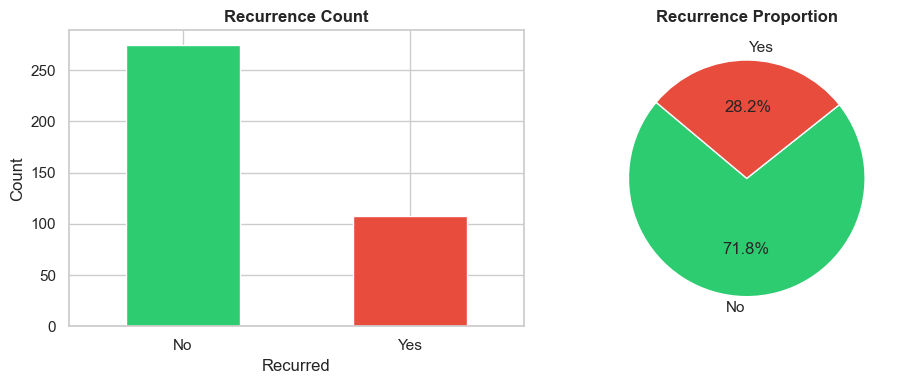

In [5]:
# Target distribution
target = 'Recurred'
counts = df[target].value_counts()
pct    = df[target].value_counts(normalize=True) * 100

print('Target Distribution:')
for cls in counts.index:
    print(f'  {cls}: {counts[cls]:>3}  ({pct[cls]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts.plot.bar(ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0].set_title('Recurrence Count', fontweight='bold')
axes[0].set_xlabel('Recurred')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=140)
axes[1].set_title('Recurrence Proportion', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Exploratory Data Analysis (EDA)

### 3.1 Numerical Feature Analysis — Age

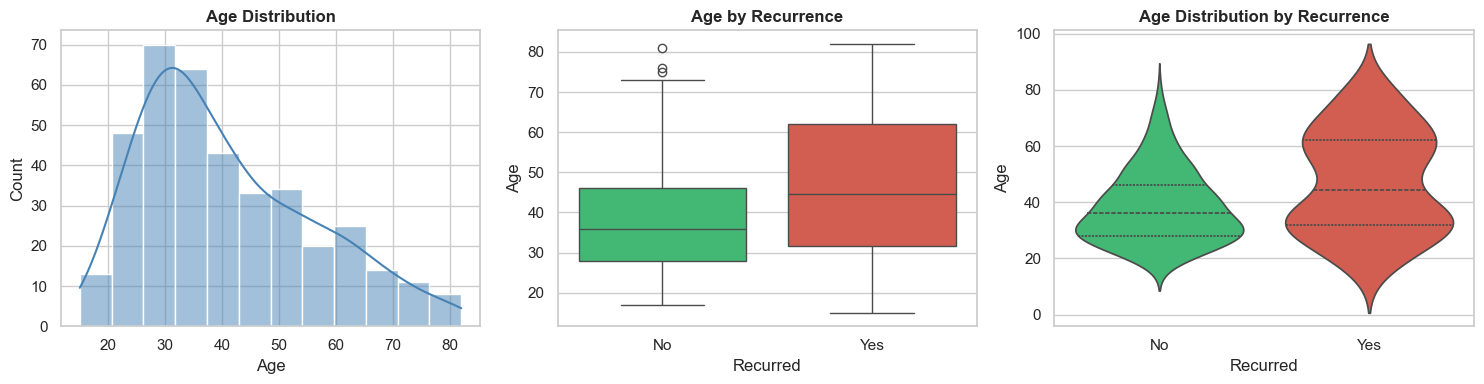


Welch t-test — Age vs Recurred
  Mean (No):  38.4 ± 12.9
  Mean (Yes): 47.1 ± 18.3
  t-statistic: -4.521,  p-value: 1.2330e-05
  => SIGNIFICANT (α=0.05)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram with KDE
sns.histplot(data=df, x='Age', kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution', fontweight='bold')

# Boxplot: Age vs Target
sns.boxplot(data=df, x=target, y='Age', ax=axes[1],
            palette={'No':'#2ecc71', 'Yes':'#e74c3c'})
axes[1].set_title('Age by Recurrence', fontweight='bold')

# Violin plot
sns.violinplot(data=df, x=target, y='Age', ax=axes[2],
               palette={'No':'#2ecc71', 'Yes':'#e74c3c'}, inner='quartile')
axes[2].set_title('Age Distribution by Recurrence', fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical test
g1 = df[df[target]=='No']['Age']
g2 = df[df[target]=='Yes']['Age']
t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
print(f'\nWelch t-test — Age vs Recurred')
print(f'  Mean (No):  {g1.mean():.1f} ± {g1.std():.1f}')
print(f'  Mean (Yes): {g2.mean():.1f} ± {g2.std():.1f}')
print(f'  t-statistic: {t_stat:.3f},  p-value: {p_val:.4e}')
print(f'  => {"SIGNIFICANT" if p_val < 0.05 else "Not significant"} (α=0.05)')

### 3.2 Categorical Feature Analysis

In [7]:
cat_features = [c for c in df.columns if c not in ['Age', 'Recurred']]
num_features = ['Age']
print(f'Categorical features ({len(cat_features)}):', cat_features)

Categorical features (15): ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response']


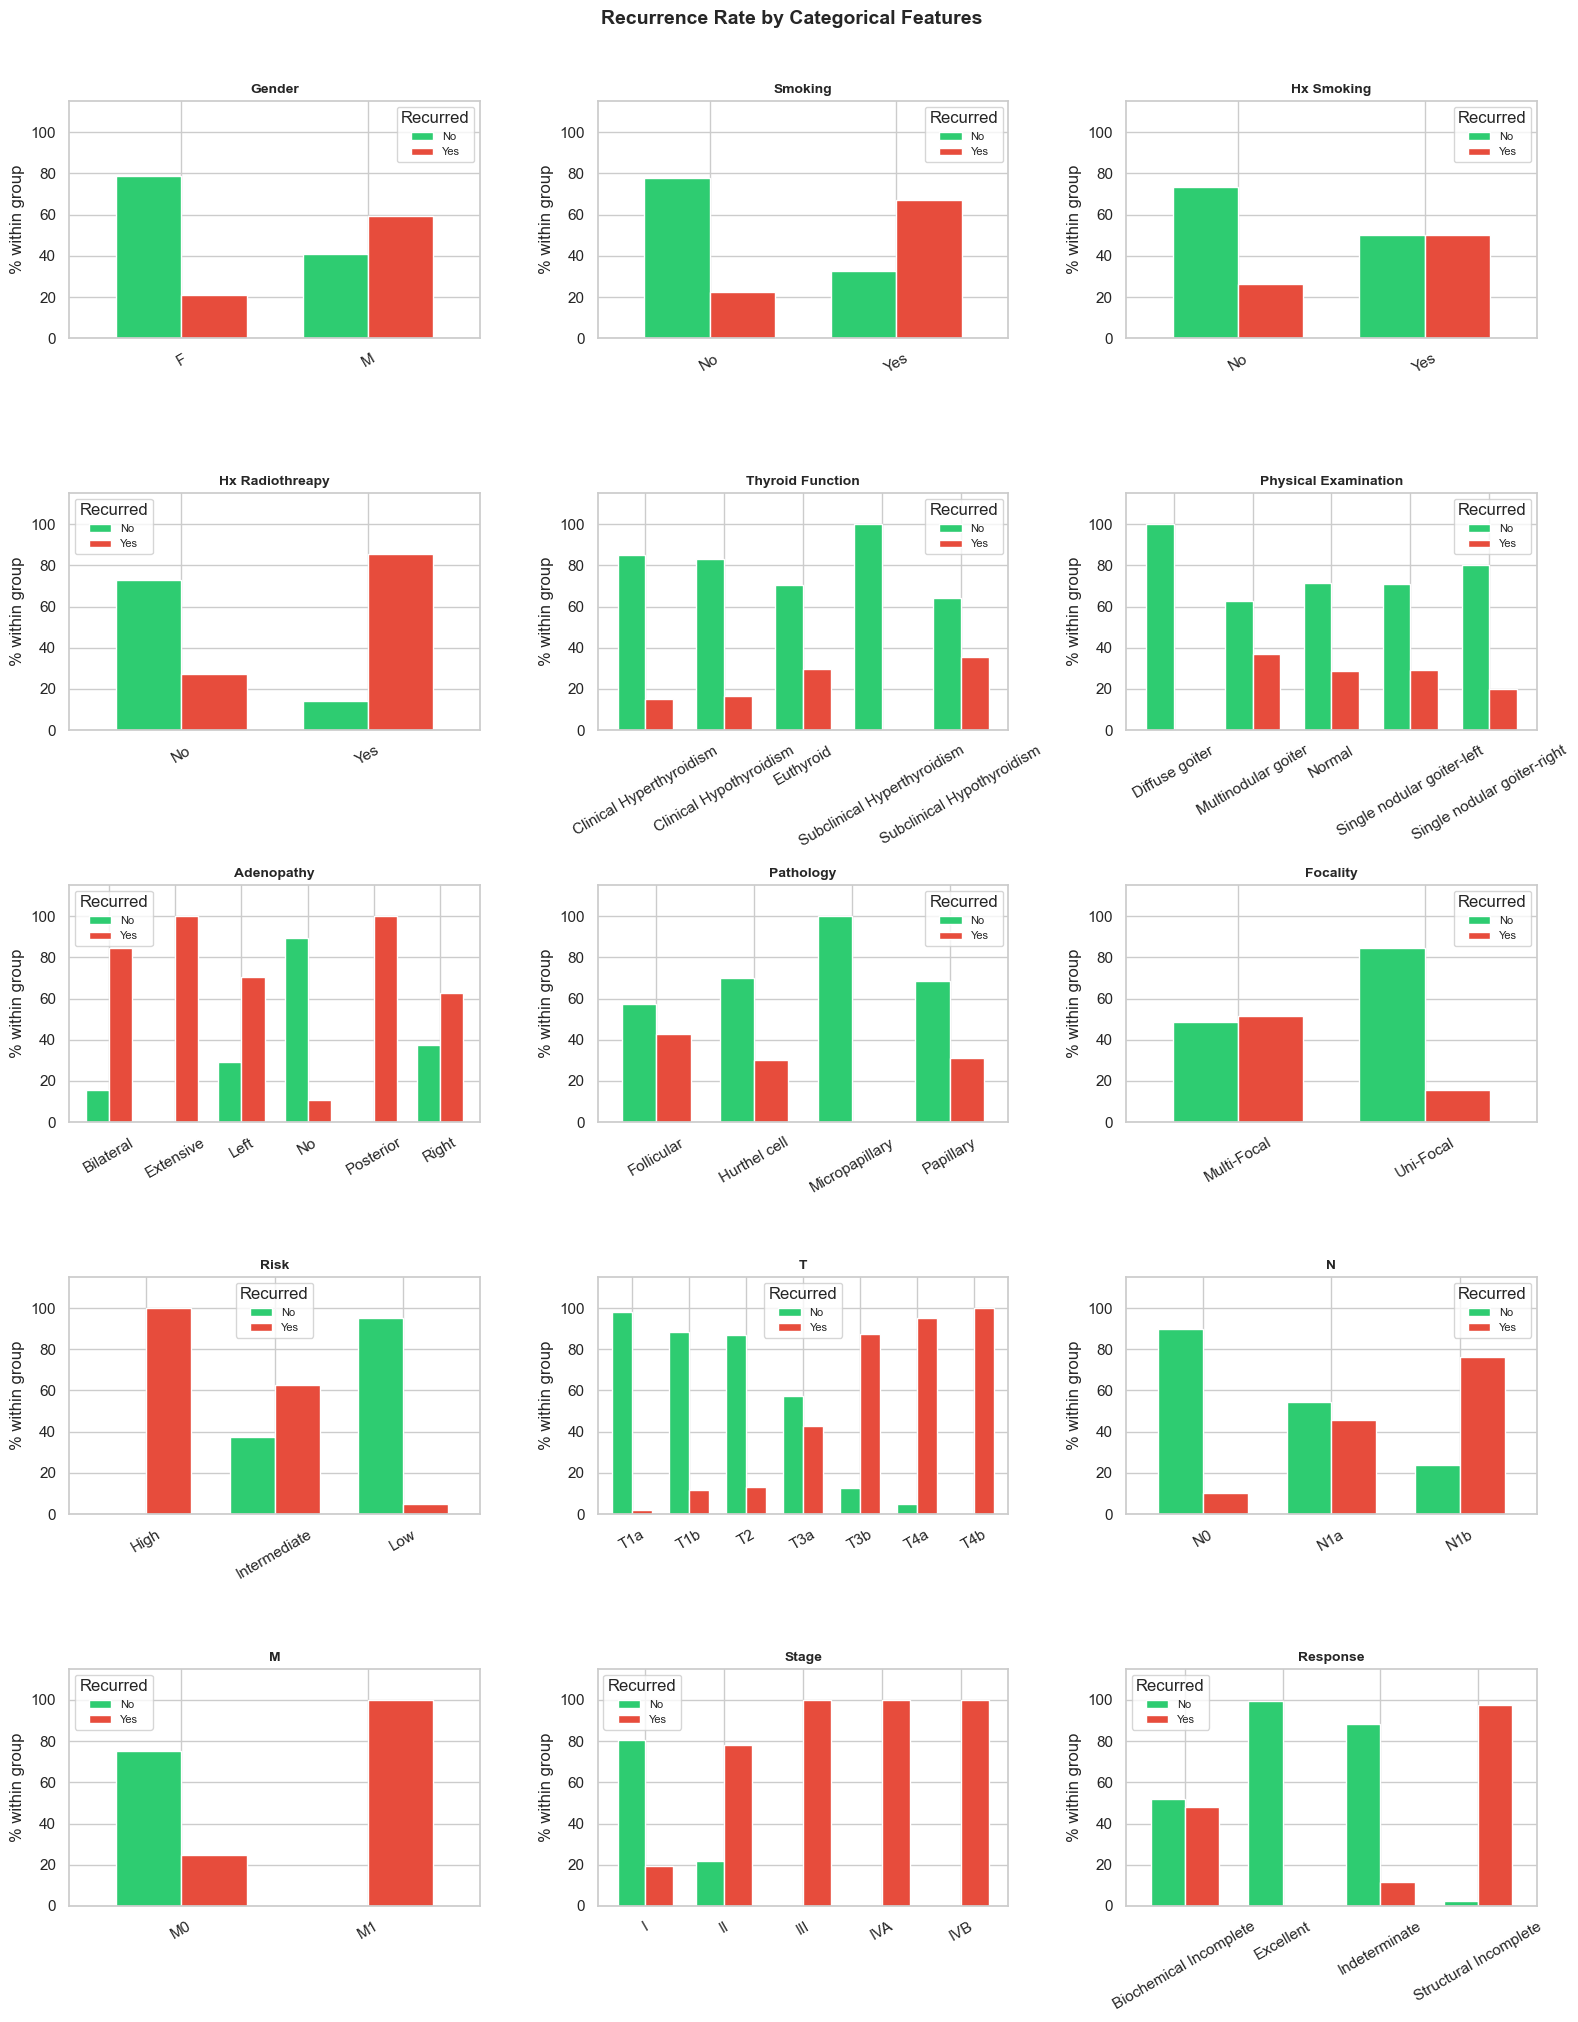

In [8]:
n_cols = 3
n_rows = (len(cat_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ax = axes[i]
    # Normalize to show proportions within each category
    ct = df.groupby([col, target]).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'],
                edgecolor='white', width=0.7)
    ax.set_title(f'{col}', fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('% within group')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Recurred', fontsize=8)
    ax.set_ylim(0, 115)

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Recurrence Rate by Categorical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Chi-Square Statistical Tests (Categorical vs Target)

In [9]:
def chi_square_test(df, col, target):
    contingency_table = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    return {
        'Feature': col,
        'Chi2 Statistic': round(chi2, 3),
        'p-value': round(p, 4),
        'Degrees of Freedom': dof,
        'Significant': 'Yes ✅' if p < 0.05 else 'No ❌'
    }

results = [chi_square_test(df, col, target) for col in cat_features]
chi2_df = pd.DataFrame(results).set_index('Feature')
chi2_df = chi2_df.sort_values('Chi2 Statistic', ascending=False)

print('Chi-Square Test Results (Categorical Features vs Recurred)')
print('='*65)
chi2_df

Chi-Square Test Results (Categorical Features vs Recurred)


,Chi2 Statistic,p-value,Degrees of Freedom,Significant
Feature,,,,
Response,309.472,0.0000,3,Yes ✅
Risk,208.826,0.0000,2,Yes ✅
Adenopathy,157.044,0.0000,5,Yes ✅
N,153.187,0.0000,2,Yes ✅
T,141.290,0.0000,6,Yes ✅
Stage,97.618,0.0000,4,Yes ✅
Focality,54.642,0.0000,1,Yes ✅
M,44.444,0.0000,1,Yes ✅
Smoking,40.344,0.0000,1,Yes ✅


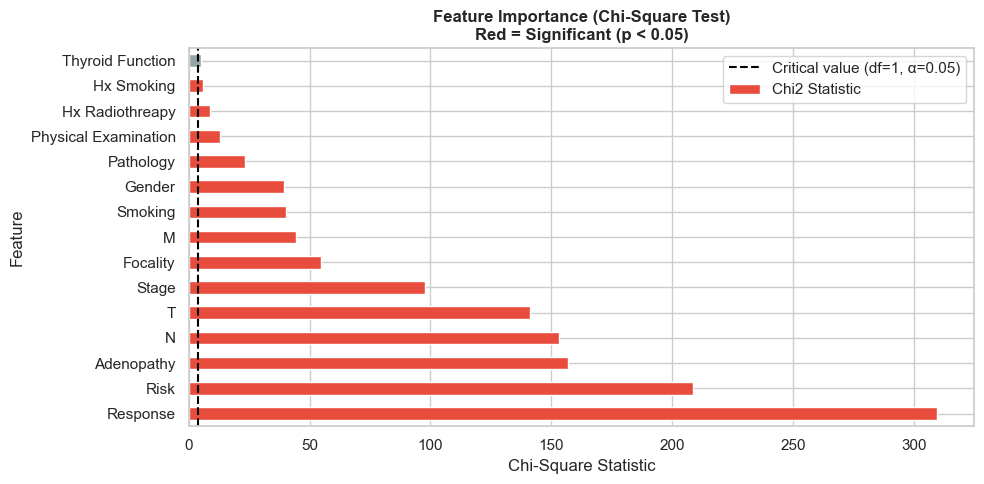


Significant features (14): ['Response', 'Risk', 'Adenopathy', 'N', 'T', 'Stage', 'Focality', 'M', 'Smoking', 'Gender', 'Pathology', 'Physical Examination', 'Hx Radiothreapy', 'Hx Smoking']
Dropped (not significant): ['Thyroid Function']


In [10]:
# Visual: Chi2 statistic bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if p < 0.05 else '#95a5a6'
          for p in chi2_df['p-value']]
chi2_df['Chi2 Statistic'].plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Chi-Square Statistic')
ax.set_title('Feature Importance (Chi-Square Test)\nRed = Significant (p < 0.05)', fontweight='bold')
ax.axvline(x=3.84, color='black', linestyle='--', linewidth=1.5, label='Critical value (df=1, α=0.05)')
ax.legend()
plt.tight_layout()
plt.show()

# List significant features
sig_cat_feat = chi2_df[chi2_df['p-value'] < 0.05].index.tolist()
insig_cat_feat = chi2_df[chi2_df['p-value'] >= 0.05].index.tolist()
print(f'\nSignificant features ({len(sig_cat_feat)}): {sig_cat_feat}')
print(f'Dropped (not significant): {insig_cat_feat}')

## 4. Feature Engineering & Encoding

In [11]:
df_enc = df.copy()

# --- Ordinal Mappings (clinically ordered) ---
ordinal_mappings = {
    'Risk':     {'Low': 1, 'Intermediate': 2, 'High': 3},
    'T':        {'T1a': 1, 'T1b': 2, 'T2': 3, 'T3a': 4, 'T3b': 5, 'T4a': 6, 'T4b': 7},
    'N':        {'N0': 0, 'N1a': 1, 'N1b': 2},
    'M':        {'M0': 0, 'M1': 1},
    'Stage':    {'I': 1, 'II': 2, 'III': 3, 'IVA': 4, 'IVB': 5},
    'Response': {'Excellent': 1, 'Indeterminate': 2,
                 'Biochemical Incomplete': 3, 'Structural Incomplete': 4},
}

for feat, mapping in ordinal_mappings.items():
    df_enc[feat] = df_enc[feat].map(mapping)

# --- Nominal Features → Label Encoding ---
nominal_binary = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Focality', 'Recurred']
binary_mappings = {
    'Gender':          {'F': 0, 'M': 1},
    'Smoking':         {'No': 0, 'Yes': 1},
    'Hx Smoking':      {'No': 0, 'Yes': 1},
    'Hx Radiothreapy': {'No': 0, 'Yes': 1},
    'Focality':        {'Uni-Focal': 0, 'Multi-Focal': 1},
    'Recurred':        {'No': 0, 'Yes': 1},
}
for feat, mapping in binary_mappings.items():
    df_enc[feat] = df_enc[feat].map(mapping)

# --- Multi-class nominal → Label Encoding ---
le = LabelEncoder()
nominal_multi = ['Physical Examination', 'Adenopathy', 'Pathology']
for feat in nominal_multi:
    df_enc[feat] = le.fit_transform(df_enc[feat])

# Drop non-significant + irrelevant columns
drop_cols = ['Thyroid Function']  # not significant
df_enc.drop(columns=drop_cols, inplace=True)

print('Encoded DataFrame shape:', df_enc.shape)
df_enc.head(3)

Encoded DataFrame shape: (383, 16)


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,0,0,0,0,3,3,2,0,1,1,0,0,1,2,0
1,34,0,0,1,0,1,3,2,0,1,1,0,0,1,1,0
2,30,0,0,0,0,4,3,2,0,1,1,0,0,1,1,0


### 4.1 Correlation Heatmap (Post-Encoding)

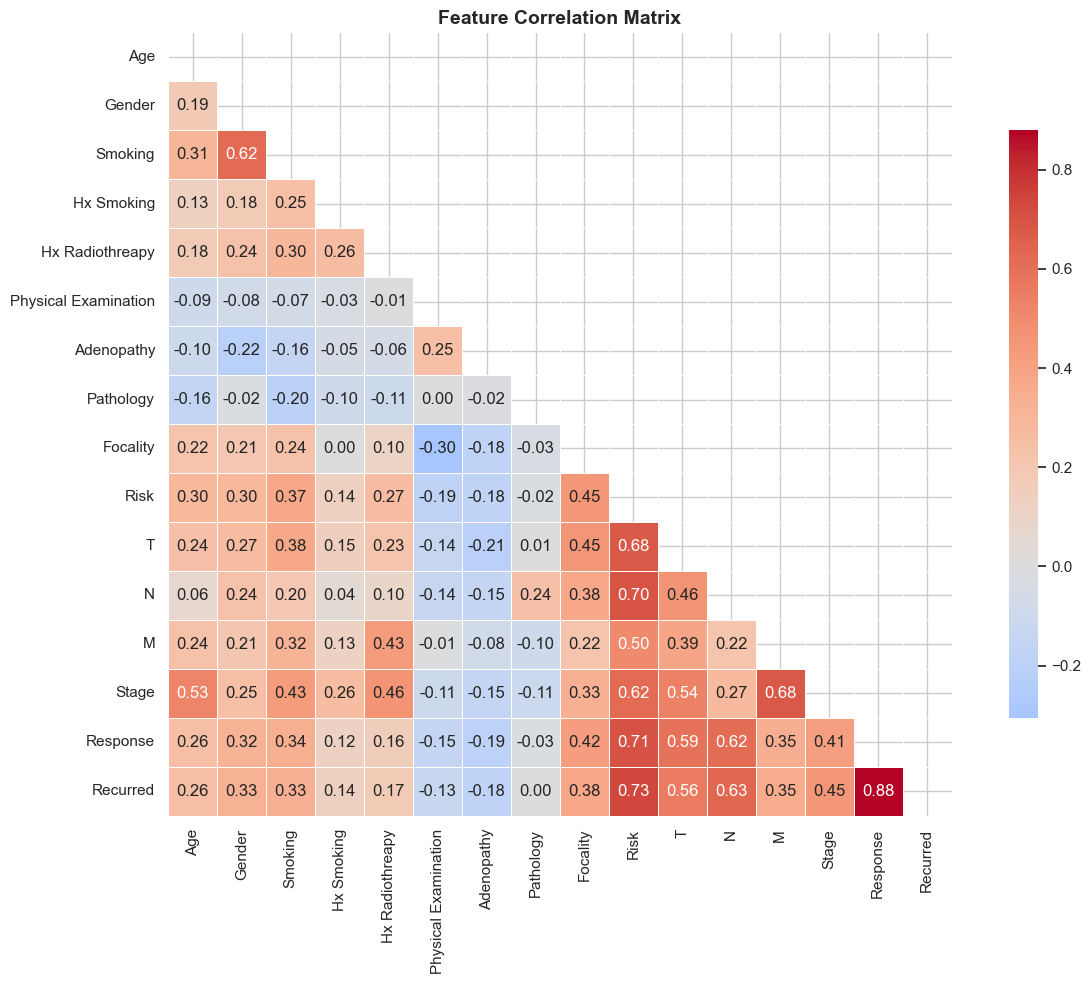


Top Correlations with Target (Recurred):
  Response                  0.879
  Risk                      0.733
  N                         0.632
  T                         0.556
  Stage                     0.449
  Focality                  0.384
  M                         0.354
  Smoking                   0.333
  Gender                    0.328
  Age                       0.259
  Adenopathy                0.183
  Hx Radiothreapy           0.174
  Hx Smoking                0.136
  Physical Examination      0.132
  Pathology                 0.003


In [12]:
fig, ax = plt.subplots(figsize=(13, 10))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.75}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
print('\nTop Correlations with Target (Recurred):')
target_corr = corr['Recurred'].drop('Recurred').abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    print(f'  {feat:<25} {val:.3f}')

## 5. Model Building & Evaluation

In [13]:
X = df_enc.drop(columns=['Recurred'])
y = df_enc['Recurred']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} samples  |  Test size: {X_test.shape[0]} samples')
print(f'Class balance in train → No: {(y_train==0).sum()}, Yes: {(y_train==1).sum()}')
print(f'Class balance in test  → No: {(y_test==0).sum()}, Yes: {(y_test==1).sum()}')

Train size: 306 samples  |  Test size: 77 samples
Class balance in train → No: 220, Yes: 86
Class balance in test  → No: 55, Yes: 22


In [14]:
# ── 5-Fold Stratified Cross-Validation ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression':   LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':         DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
}

cv_results = {}
for name, model in models.items():
    X_cv = X_train_sc if name == 'Logistic Regression' else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = scores
    print(f'{name:<25}  AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression        AUC: 0.9875 ± 0.0105
Decision Tree              AUC: 0.9315 ± 0.0287
Random Forest              AUC: 0.9880 ± 0.0159
Gradient Boosting          AUC: 0.9726 ± 0.0200


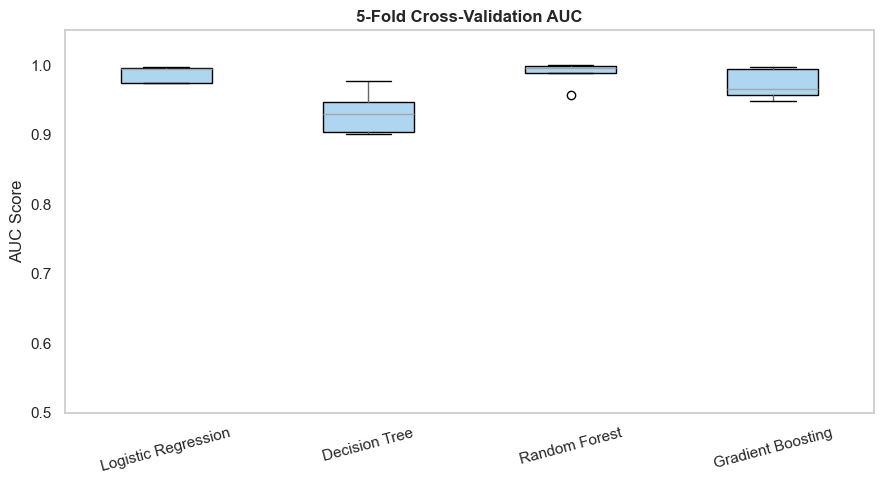

In [15]:
# Cross-validation box-plot
fig, ax = plt.subplots(figsize=(9, 5))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax, grid=False, patch_artist=True,
              boxprops=dict(facecolor='#AED6F1'))
ax.set_title('5-Fold Cross-Validation AUC', fontweight='bold')
ax.set_ylabel('AUC Score')
ax.set_ylim(0.5, 1.05)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

In [16]:
# ── Train on full train set & Evaluate on test set ──
test_results = []
trained_models = {}

for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    
    model.fit(X_tr, y_train)
    trained_models[name] = model
    
    y_pred     = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1]
    
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_pred_proba)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    
    test_results.append({
        'Model':     name,
        'Accuracy':  round(acc,  4),
        'AUC-ROC':   round(auc,  4),
        'Precision': round(report['1']['precision'], 4),
        'Recall':    round(report['1']['recall'],    4),
        'F1-Score':  round(report['1']['f1-score'],  4),
    })

results_df = pd.DataFrame(test_results).set_index('Model').sort_values('AUC-ROC', ascending=False)
print('\nTest Set Performance:')
results_df


Test Set Performance:


,Accuracy,AUC-ROC,Precision,Recall,F1-Score
Model,,,,,
Logistic Regression,0.9610,0.9942,0.9524,0.9091,0.9302
Random Forest,0.9740,0.9926,1.0000,0.9091,0.9524
Gradient Boosting,0.9610,0.9917,1.0000,0.8636,0.9268
Decision Tree,0.9351,0.8934,0.9474,0.8182,0.8780


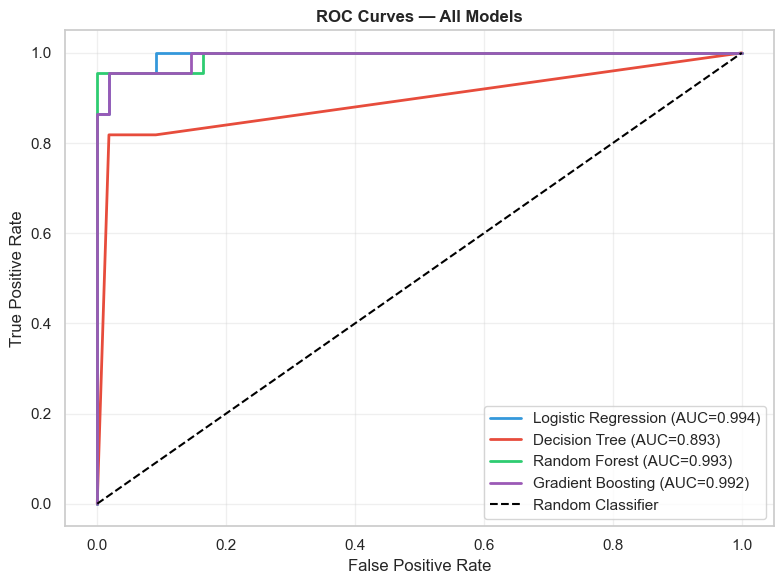

In [17]:
# ── ROC Curves ──
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for (name, model), color in zip(trained_models.items(), colors):
    X_te = X_test_sc if name == 'Logistic Regression' else X_test
    y_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

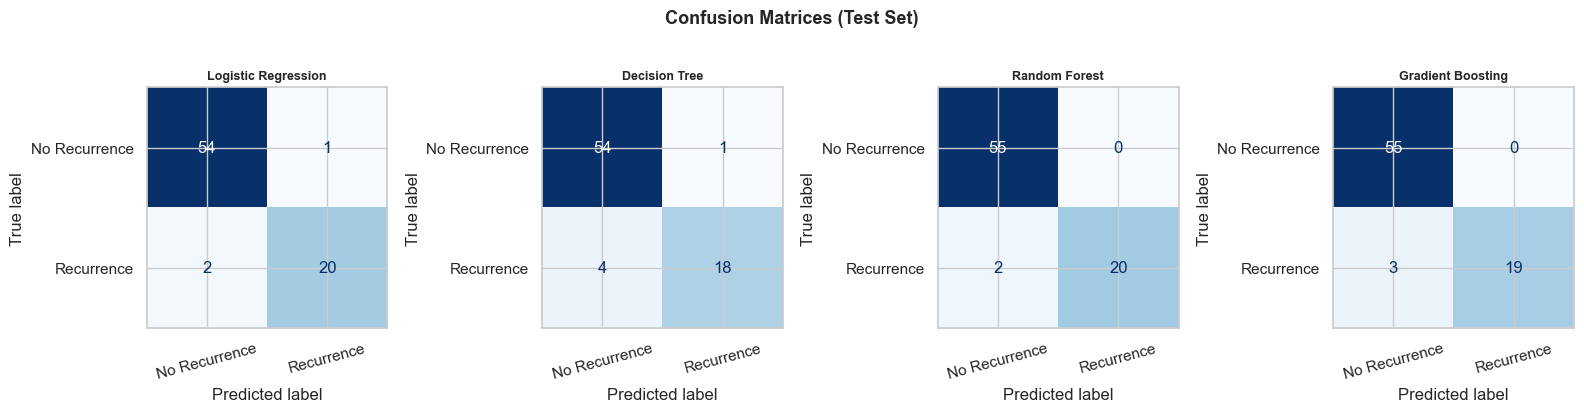

In [18]:
# ── Confusion Matrices ──
fig, axes = plt.subplots(1, len(trained_models), figsize=(16, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    X_te = X_test_sc if name == 'Logistic Regression' else X_test
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Recurrence', 'Recurrence'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Confusion Matrices (Test Set)', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Feature Importance (Best Model)

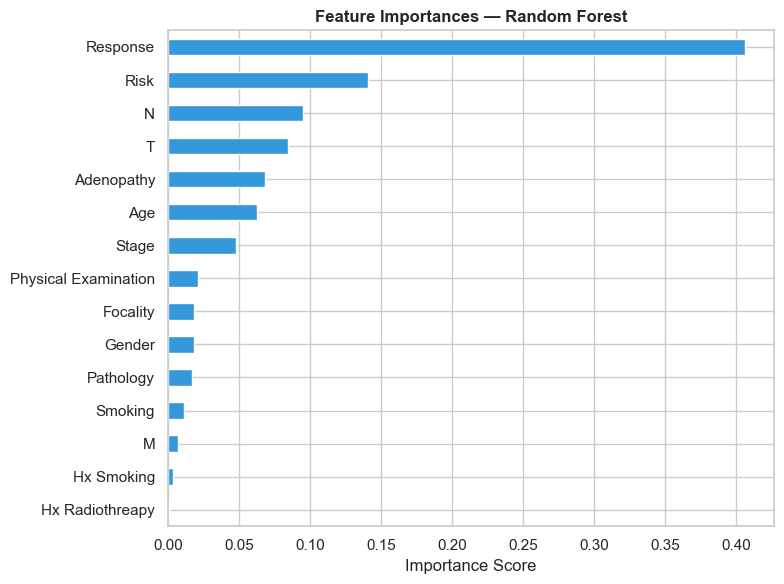


Top 5 most important features:
  Response                  0.4064
  Risk                      0.1405
  N                         0.0950
  T                         0.0840
  Adenopathy                0.0681


In [19]:
# Use Random Forest feature importance (generally most interpretable)
best_model_name = 'Random Forest'
rf_model = trained_models[best_model_name]

feat_imp = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_title(f'Feature Importances — {best_model_name}', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
for feat, score in feat_imp.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<25} {score:.4f}')

### 6.1 Logistic Regression Coefficients (Odds Ratios)

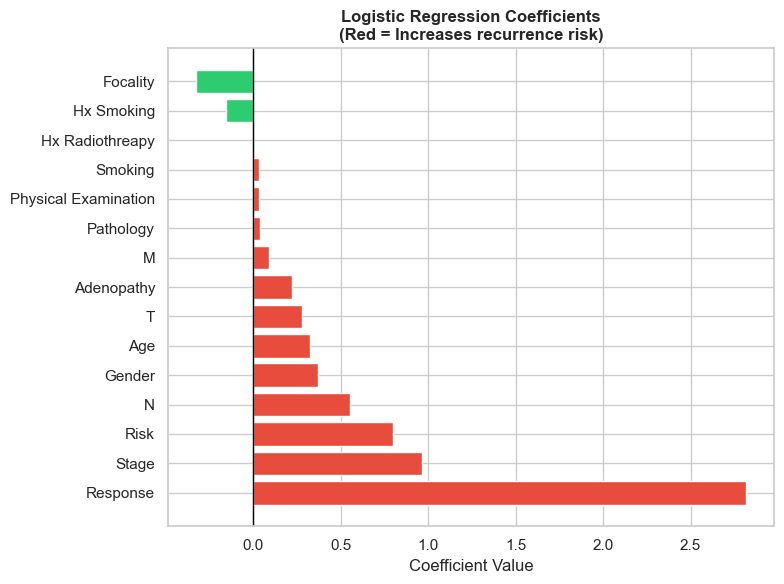


Logistic Regression — Odds Ratios:
             Feature  Coefficient  Odds Ratio
            Response     2.818812   16.756932
               Stage     0.966827    2.629588
                Risk     0.799741    2.224964
                   N     0.550907    1.734827
              Gender     0.368629    1.445751
                 Age     0.325286    1.384427
                   T     0.278931    1.321716
          Adenopathy     0.220074    1.246169
                   M     0.090851    1.095106
           Pathology     0.037912    1.038640
Physical Examination     0.034817    1.035430
             Smoking     0.033816    1.034394
     Hx Radiothreapy    -0.000333    0.999667
          Hx Smoking    -0.158760    0.853201
            Focality    -0.328409    0.720068


In [20]:
lr_model = trained_models['Logistic Regression']
coef_df = pd.DataFrame({
    'Feature':  X.columns,
    'Coefficient': lr_model.coef_[0],
    'Odds Ratio': np.exp(lr_model.coef_[0])
}).sort_values('Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Logistic Regression Coefficients\n(Red = Increases recurrence risk)', fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print('\nLogistic Regression — Odds Ratios:')
print(coef_df[['Feature','Coefficient','Odds Ratio']].to_string(index=False))

## 7. Summary & Conclusions

In [21]:
print('='*60)
print('         THYROID CANCER RECURRENCE — SUMMARY')
print('='*60)
print(f'\n📦 Dataset: 383 patients | 17 features | Binary target')
print(f'\n🔍 EDA Findings:')
print(f'   • No missing values in the dataset.')
print(f'   • Target imbalanced (~{pct.get("No", 0):.0f}% No, ~{pct.get("Yes", 0):.0f}% Yes).')
print(f'   • Age is significantly higher in recurred group (t-test p<0.05).')
print(f'   • Thyroid Function showed NO significant association (Chi-Sq p>0.05).')
print(f'   • Response, Risk, Adenopathy — strongest predictors by Chi-Square.')

print(f'\n🏆 Model Performance (Test Set):')
print(results_df.to_string())

best = results_df.iloc[0]
print(f'\n✅ Best Model: {results_df.index[0]}')
print(f'   AUC-ROC:  {best["AUC-ROC"]}')
print(f'   Accuracy: {best["Accuracy"]}')
print(f'   F1-Score: {best["F1-Score"]}')
print('='*60)

         THYROID CANCER RECURRENCE — SUMMARY

📦 Dataset: 383 patients | 17 features | Binary target

🔍 EDA Findings:
   • No missing values in the dataset.
   • Target imbalanced (~72% No, ~28% Yes).
   • Age is significantly higher in recurred group (t-test p<0.05).
   • Thyroid Function showed NO significant association (Chi-Sq p>0.05).
   • Response, Risk, Adenopathy — strongest predictors by Chi-Square.

🏆 Model Performance (Test Set):
                     Accuracy  AUC-ROC  Precision  Recall  F1-Score
Model                                                              
Logistic Regression    0.9610   0.9942     0.9524  0.9091    0.9302
Random Forest          0.9740   0.9926     1.0000  0.9091    0.9524
Gradient Boosting      0.9610   0.9917     1.0000  0.8636    0.9268
Decision Tree          0.9351   0.8934     0.9474  0.8182    0.8780

✅ Best Model: Logistic Regression
   AUC-ROC:  0.9942
   Accuracy: 0.961
   F1-Score: 0.9302


In [22]:
model

GradientBoostingClassifier(n_estimators=200, random_state=42)

In [23]:
test_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.961,
  'AUC-ROC': np.float64(0.9942),
  'Precision': 0.9524,
  'Recall': 0.9091,
  'F1-Score': 0.9302},
 {'Model': 'Decision Tree',
  'Accuracy': 0.9351,
  'AUC-ROC': np.float64(0.8934),
  'Precision': 0.9474,
  'Recall': 0.8182,
  'F1-Score': 0.878},
 {'Model': 'Random Forest',
  'Accuracy': 0.974,
  'AUC-ROC': np.float64(0.9926),
  'Precision': 1.0,
  'Recall': 0.9091,
  'F1-Score': 0.9524},
 {'Model': 'Gradient Boosting',
  'Accuracy': 0.961,
  'AUC-ROC': np.float64(0.9917),
  'Precision': 1.0,
  'Recall': 0.8636,
  'F1-Score': 0.9268}]

In [24]:
X_train

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response
331,51,0,0,0,0,3,3,0,0,2,4,0,0,1,4
348,58,0,0,0,0,1,1,3,1,2,5,2,0,2,4
122,28,0,0,0,0,3,3,3,0,1,3,0,0,1,1
359,35,0,0,0,0,1,1,3,1,3,6,2,0,1,4
366,64,0,0,1,0,1,3,0,1,3,6,0,1,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,30,0,0,0,0,2,5,0,0,1,4,0,0,1,1
346,32,1,0,1,0,1,0,3,1,2,5,2,0,1,4
264,41,0,0,0,0,1,3,3,1,1,4,0,0,1,3
63,54,0,0,0,0,1,3,3,0,1,2,0,0,1,2


In [25]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)



LogisticRegression()

In [26]:
data = { 'features' : list(X_train.columns)}
data

{'features': ['Age',
  'Gender',
  'Smoking',
  'Hx Smoking',
  'Hx Radiothreapy',
  'Physical Examination',
  'Adenopathy',
  'Pathology',
  'Focality',
  'Risk',
  'T',
  'N',
  'M',
  'Stage',
  'Response']}

In [27]:
with open("Thyroid_fetures.pkl" , "wb") as f:
    pickle.dump(data, f)

NameError: name 'pickle' is not defined

In [ ]:
df

In [ ]:
cat_features

In [28]:
data1 = dict()

for col in sig_cat_feat:
    data1[col] = list(df[col].unique())
data1

{'Response': ['Indeterminate',
  'Excellent',
  'Structural Incomplete',
  'Biochemical Incomplete'],
 'Risk': ['Low', 'Intermediate', 'High'],
 'Adenopathy': ['No', 'Right', 'Extensive', 'Left', 'Bilateral', 'Posterior'],
 'N': ['N0', 'N1b', 'N1a'],
 'T': ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'],
 'Stage': ['I', 'II', 'IVB', 'III', 'IVA'],
 'Focality': ['Uni-Focal', 'Multi-Focal'],
 'M': ['M0', 'M1'],
 'Smoking': ['No', 'Yes'],
 'Gender': ['F', 'M'],
 'Pathology': ['Micropapillary', 'Papillary', 'Follicular', 'Hurthel cell'],
 'Physical Examination': ['Single nodular goiter-left',
  'Multinodular goiter',
  'Single nodular goiter-right',
  'Normal',
  'Diffuse goiter'],
 'Hx Radiothreapy': ['No', 'Yes'],
 'Hx Smoking': ['No', 'Yes']}

In [30]:
X_train.columns

Index(['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk',
       'T', 'N', 'M', 'Stage', 'Response'],
      dtype='object')